In [19]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

In [23]:
def uniform_cost_search(graph, start, goal):

    priority_queue = [(0, start)]

    visited = {start: (0, None)}

    while priority_queue:

        current_cost, current_node = heapq.heappop(priority_queue)


        if current_node == goal:
            return current_cost, reconstruct_path(visited, start, goal)


        for neighbor, cost in graph[current_node]:
            total_cost = current_cost + cost

            if neighbor not in visited or total_cost < visited[neighbor][0]:
                visited[neighbor] = (total_cost, current_node)
                heapq.heappush(priority_queue, (total_cost, neighbor))

    return None

In [24]:
def reconstruct_path(visited, start, goal):

    path = []
    current = goal
    while current is not None:
        path.append(current)
        current = visited[current][1]
    path.reverse()
    return path

Least cost path from S to D: S -> C -> E -> D with total cost 8


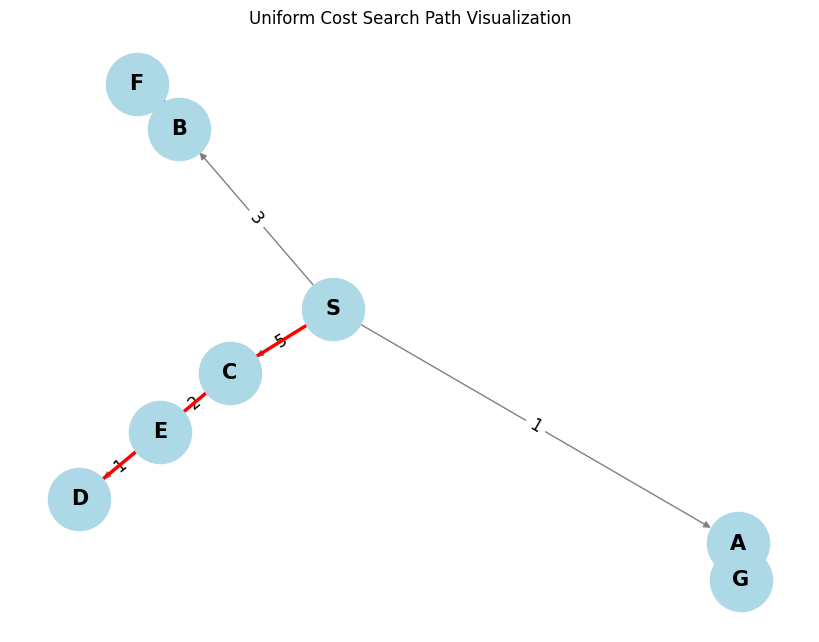

In [25]:
graph={
    'S':[('A',1),('B',3),('C',5)],
    'A':[('G',3)],
    'B':[('F',5)],
    'C':[('E',2)],
    'E':[('D',1)],
    'G':[],
    'F':[],
    'D':[]
}
start_node = 'S'
goal_node = 'D'
result = uniform_cost_search(graph, start_node, goal_node)

if result:
    total_cost, path = result
    print(f"Least cost path from {start_node} to {goal_node}: {' -> '.join(path)} with total cost {total_cost}")
    visualize_graph(graph, path)
else:
    print(f"No path found from {start_node} to {goal_node}")